# {Final Project Climate Change}📝

![Banner](./assets/banner.jpeg)

## Topic
*What problem are you (or your stakeholder) trying to address?*
📝 <!-- Answer Below -->

### The topic I'm trying to address is climate change.

## Project Question
*What specific question are you seeking to answer with this project?*
*This is not the same as the questions you ask to limit the scope of the project.*
📝 <!-- Answer Below -->

### How do emissions relate to climate change trends?

## What would an answer look like?
*What is your hypothesized answer to your question?*
📝 <!-- Answer Below -->

### Emissions relate to climate change trends because greenhouse gases, mainly carbon dioxide from burning fossil fuels, deforestation, and agriculture, act as a heat trapping blanket, which directly causes global warming and climate change.

## Data Sources
*What 3 data sources have you identified for this project?*
*How are you going to relate these datasets?*
📝 <!-- Answer Below -->

Data set Files:

Database: https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv

Carbon (CO2) emissions - https://www.kaggle.com/datasets/ravindrasinghrana/carbon-co2-emissions

Greenhouse Gas Emissions - https://www.kaggle.com/datasets/willianoliveiragibin/greenhouse-gas-emissions

Global emissions - https://www.kaggle.com/datasets/ashishraut64/global-methane-emissions


I will use the dataset from Our World in Data, which has a complete global data on emissions, population, and other climate-related indicators. I will store and structure this dataset in a relational database using SQLite.

I will merge the kaggle datasets using common variables like country and year as both datasets include emissions data for different countries for various years.

I will create the following tables countries, emissions, and population from Ourworld dataset and I will create a unique identifier country_id accross these tables to join them. I will then join the dataset from this to kaggle data sets using country name and year

## Approach and Analysis
*What is your approach to answering your project question?*
*How will you use the identified data to answer your project question?*
📝 <!-- Start Discussing the project here; you can add as many code cells as you need -->

My approach is to combine emissions data from multiple datasets and analyze trends over time. I will clean and merge the datasets using common variables such as country and year. The data will be stored and queried using a SQLite database. I will then create visualizations, such as line charts, to observe how emissions change over time and compare patterns across countries. This analysis will help determine how emissions relate to climate change trends.

In [9]:
# Import necessary libraries for data manipulation and visualization.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3


In [10]:
# Import the data from Our World in Data and store it in a DataFrame.

url = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"
df = pd.read_csv(url)

df.sample(5)

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
1877,Antarctica,1927,ATA,NaN,NaN,0.000,NaN,NaN,NaN,NaN,...,NaN,0.000,NaN,0.000,0.000,NaN,NaN,NaN,NaN,NaN
44083,Sweden,1987,SWE,8397651.0,2.268804e+11,1.148,0.137,59.695,-2.315,-3.733,...,NaN,0.347,0.0,0.003,0.003,0.0,66.681,69.342,NaN,NaN
45916,Tunisia,1866,TUN,1315628.0,NaN,0.000,0.000,NaN,NaN,NaN,...,NaN,0.028,0.0,0.000,0.000,0.0,1.512,0.212,NaN,NaN
36262,Palestine,1876,PSE,215317.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,-0.000,NaN,-0.000,-0.000,NaN,NaN,NaN,NaN,NaN
36791,Papua New Guinea,1955,PNG,1739220.0,NaN,0.000,0.000,0.128,0.033,34.615,...,NaN,0.125,0.0,0.001,0.001,0.0,-2.420,0.610,NaN,NaN


In [11]:
# Create a new DataFrame with the relevant columns for distinct countries and assign a unique country_id to each country.
countries = df[["country"]].drop_duplicates().reset_index(drop=True)

# Assign a unique country_id to each country using the index of the DataFrame. Adding 1 to start the country_id from 1 instead of 0.
countries["country_id"] = countries.index + 1

countries.sample(10)

,country,country_id
106,International shipping,107
201,Sao Tome and Principe,202
148,Moldova,149
120,Kuwaiti Oil Fires,121
194,Saint Helena,195
40,Cameroon,41
65,East Timor,66
149,Monaco,150
209,Slovakia,210
198,Saint Vincent and the Grenadines,199


In [39]:
# Merge the country_id back to the main DataFrame

df = df.merge(countries, on="country")
df.sample(10)

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share,country_id_x,country_id_y
26855,Low-income countries,1771,NaN,NaN,NaN,0.000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,133,133
47147,Ukraine,1939,UKR,33620144.0,NaN,0.454,0.014,78.669,0.953,1.226,...,0.002,0.003,0.005,0.000,201.840,105.016,NaN,NaN,239,239
22253,International shipping,1790,NaN,NaN,NaN,0.000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,107,107
26793,Lithuania,1984,LTU,3534123.0,4.904552e+10,1.412,0.399,37.601,0.358,0.960,...,0.000,0.001,0.001,0.000,51.418,41.220,NaN,NaN,132,132
35055,OECD (GCP),1994,NaN,NaN,NaN,NaN,NaN,12366.514,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,174,174
22424,International shipping,1961,NaN,NaN,NaN,0.000,NaN,243.427,21.348,9.613,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,107,107
29840,Micronesia (country),2006,FSM,110739.0,NaN,0.000,0.000,0.114,0.000,0.000,...,0.000,0.000,0.000,0.000,0.172,0.119,NaN,NaN,147,147
7853,Burkina Faso,1865,BFA,1933297.0,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000,-0.000,0.000,0.000,1.570,0.369,NaN,NaN,38,38
43213,South Sudan,2024,SSD,11943410.0,NaN,0.000,0.000,1.696,0.029,1.756,...,0.001,0.001,0.003,0.001,58.846,6.083,NaN,NaN,218,218
5621,Benin,1856,BEN,818998.0,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.000,-0.000,-0.000,0.000,-1.297,0.216,NaN,NaN,27,27


In [13]:
# Create a new DataFrame with the relevant columns for emissions.
population = df[["country_id", "year", "population"]]
population.head()

,country_id,year,population
0,1,1750,2802560.0
1,1,1751,NaN
2,1,1752,NaN
3,1,1753,NaN
4,1,1754,NaN


In [14]:
# Create a new DataFrame with the relevant columns for emissions.
emissions = df[["country_id", "year", "co2", "methane"]]

emissions.sample(5)

,country_id,year,co2,methane
36069,180,1858,NaN,0.001
17057,83,1915,0.106,3.343
45686,232,1911,0.125,0.262
42438,215,1774,NaN,NaN
30791,153,1904,NaN,NaN


In [15]:
# Store the DataFrames in a SQLite database.
conn = sqlite3.connect("climate.db")

countries.to_sql("countries", conn, if_exists="replace", index=False)
emissions.to_sql("emissions", conn, if_exists="replace", index=False)
population.to_sql("population", conn, if_exists="replace", index=False)

50411

In [132]:
# Write a SQL query to join the three tables and retrieve the country name, year, CO2 emissions, methane emissions, and population.
query = """
SELECT c.country, e.year, e.co2, e.methane, p.population
FROM emissions e
JOIN countries c ON e.country_id = c.country_id
JOIN population p ON e.country_id = p.country_id AND e.year = p.year
"""

database_result = pd.read_sql(query, conn)
database_result.sample(5)

,country,year,co2,methane,population
22655,Iran,2017,696.407,169.524,85026761.0
35274,Oceania,1763,0.000,NaN,NaN
43360,Spain,1976,197.749,33.101,36176273.0
7919,Burkina Faso,1931,NaN,2.597,3232848.0
9538,Chad,1985,0.180,7.727,5096274.0


In [165]:
# Import data from csv files imported from Kaggle and store it in DataFrames.
Methane_final_df = pd.read_table('Methane_final.csv', sep=',')
# Drop the 'Unnamed: 0' column from the Methane_final_df DataFrame, which is a unnecessary index column that was created during the CSV export process.
Methane_final_df = Methane_final_df.drop(columns=['Unnamed: 0'])

Carbon_emissions_df = pd.read_table('Carbon_(CO2)_Emissions_by_Country.csv', sep=',')

Carbon_emissions_per_capita_df = pd.read_table('co-emissions-per-capita new.csv', sep=',')

## 1. Exploratory Data Analysis (EDA)

In [45]:
# Perform basic data analysis on the database_result DataFrame to understand the structure and summary statistics of the data.
database_result.info()
database_result.describe()

<class 'pandas.DataFrame'>
RangeIndex: 50411 entries, 0 to 50410
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     50411 non-null  str    
 1   year        50411 non-null  int64  
 2   co2         29384 non-null  float64
 3   methane     38150 non-null  float64
 4   population  41167 non-null  float64
dtypes: float64(3), int64(1), str(1)
memory usage: 1.9 MB


,year,co2,methane,population
count,50411.000000,29384.000000,38150.000000,4.116700e+04
mean,1920.349249,420.227035,95.277707,6.017453e+07
std,65.859123,1972.092032,434.707032,3.308433e+08
min,1750.000000,0.000000,0.000000,2.150000e+02
25%,1875.000000,0.381000,0.389000,3.272140e+05
50%,1925.000000,5.081000,3.462500,2.291594e+06
75%,1975.000000,53.656500,18.546750,9.986553e+06
max,2024.000000,38598.578000,9498.914000,8.161973e+09


##### - My dataset from the database has yearly data for different countries showing the emission details like CO2 and methane and it also lists population.
##### - CO2, methane, and population have a lot of missing data.

In [48]:
# Checks for missing values in the database_result DataFrame.
database_result.isnull().sum()

country           0
year              0
co2           21027
methane       12261
population     9244
dtype: int64

In [66]:
# Checking the data types of the columns in the database_result DataFrame.
print(database_result.dtypes)

country           str
year            int64
co2           float64
methane       float64
population    float64
dtype: object


In [49]:
# Check for duplicates in the database_result DataFrame.
database_result.duplicated().sum()

np.int64(0)

In [51]:
# Perform basic data analysis on the Methane_final_df DataFrame to understand the structure and summary statistics of the data.
Methane_final_df.info()
Methane_final_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1548 entries, 0 to 1547
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  1548 non-null   int64  
 1   region      1548 non-null   str    
 2   country     1548 non-null   str    
 3   emissions   1548 non-null   float64
 4   type        1548 non-null   str    
 5   segment     1548 non-null   str    
 6   reason      1548 non-null   str    
 7   baseYear    1548 non-null   str    
 8   notes       1548 non-null   str    
dtypes: float64(1), int64(1), str(7)
memory usage: 109.0 KB


,Unnamed: 0,emissions
count,1548.000000,1548.000000
mean,773.500000,643.255972
std,447.013423,5566.238201
min,0.000000,0.000459
25%,386.750000,2.659361
50%,773.500000,24.064669
75%,1160.250000,128.419594
max,1547.000000,141953.765625


##### - My dataset for methane dataset shows methane emission details including the type segment etc. for each country per year

##### - This dataset doesn't have any missing values.

In [60]:
# Checking for null values in the Methane_final_df DataFrame.
Methane_final_df.isnull().sum()

Unnamed: 0    0
region        0
country       0
emissions     0
type          0
segment       0
reason        0
baseYear      0
notes         0
dtype: int64

In [56]:
# Check for duplicates in the Methane_final_df DataFrame.
Methane_final_df.duplicated().sum()

np.int64(0)

In [63]:
# Checking the data types of the columns in the Methane_final_df DataFrame.
print(Methane_final_df.dtypes)

Unnamed: 0      int64
region            str
country           str
emissions     float64
type              str
segment           str
reason            str
baseYear          str
notes             str
dtype: object


##### - The dataset for carbon emissions dataframe contains C02 emission details for each country based on a date.
##### - There is no null values in this dataset.
##### - There is no year field so, I need to a create a year field from the date to be able to join to the other datasets.

In [53]:
Carbon_emissions_df.info()
Carbon_emissions_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 5677 entries, 0 to 5676
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country                 5677 non-null   str    
 1   Region                  5677 non-null   str    
 2   Date                    5677 non-null   str    
 3   Kilotons of Co2         5677 non-null   float64
 4   Metric Tons Per Capita  5677 non-null   float64
dtypes: float64(2), str(3)
memory usage: 221.9 KB


,Kilotons of Co2,Metric Tons Per Capita
count,5.677000e+03,5677.000000
mean,1.412292e+05,4.325505
std,6.491258e+05,5.503834
min,0.000000e+00,0.000000
25%,1.380000e+03,0.570000
50%,9.170000e+03,2.360000
75%,5.848000e+04,6.340000
max,1.070722e+07,47.650000


In [ ]:
# Checked the data from the carbon emissions dataset.
Carbon_emissions_df.head(5)

,Country,Region,Date,Kilotons of Co2,Metric Tons Per Capita
0,Afghanistan,Asia,01-01-2011,8930.0,0.31
1,Afghanistan,Asia,01-01-2012,8080.0,0.27
2,Afghanistan,Asia,01-01-2010,7110.0,0.25
3,Afghanistan,Asia,01-01-2019,6080.0,0.16
4,Afghanistan,Asia,01-01-2018,6070.0,0.17


In [61]:
# Checking for null values in the Carbon_emissions_df DataFrame.
Carbon_emissions_df.isnull().sum()

Country                   0
Region                    0
Date                      0
Kilotons of Co2           0
Metric Tons Per Capita    0
dtype: int64

In [57]:
# Check for duplicates in the Carbon_emissions_df DataFrame.
Carbon_emissions_df.duplicated().sum()

np.int64(0)

In [64]:
# Checking the data types of the columns in the Carbon_emissions_df DataFrame.
print(Carbon_emissions_df.dtypes)

Country                       str
Region                        str
Date                          str
Kilotons of Co2           float64
Metric Tons Per Capita    float64
dtype: object


##### - The carbon emissions per capita has data showing annual CO2 emissions per capita. For each entity(country) per year.
##### - There are no null values for this dataset.

In [55]:
Carbon_emissions_per_capita_df.info()
Carbon_emissions_per_capita_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 26600 entries, 0 to 26599
Data columns (total 3 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Entity                             26600 non-null  str  
 1   Year                               26600 non-null  int64
 2   Annual CO₂ emissions (per capita)  26600 non-null  str  
dtypes: int64(1), str(2)
memory usage: 623.6 KB


,Year
count,26600.000000
mean,1949.096880
std,56.387496
min,1750.000000
25%,1915.000000
50%,1963.000000
75%,1994.000000
max,2022.000000


In [70]:
# Check the data from the carbon emissions per capita dataset.
Carbon_emissions_per_capita_df.sample(5)

,Entity,Year,Annual CO₂ emissions (per capita)
14883,China,1971,10.781.755
12294,Yemen,1958,35.202.742
2449,Armenia,1860,2.508.594
10885,Uruguay,1951,11.622.841
5182,Papua New Guinea,1898,0


In [62]:
# Checking for null values in the Carbon_emissions_per_capita_df DataFrame.
Carbon_emissions_per_capita_df.isnull().sum()

Entity                               0
Year                                 0
Annual CO₂ emissions (per capita)    0
dtype: int64

In [58]:
# Check for duplicates in the Carbon_emissions_per_capita_df DataFrame.
Carbon_emissions_per_capita_df.duplicated().sum()

np.int64(0)

In [65]:
# Checking the data types of the columns in the Carbon_emissions_per_capita_df DataFrame.
print(Carbon_emissions_per_capita_df.dtypes)

Entity                                 str
Year                                 int64
Annual CO₂ emissions (per capita)      str
dtype: object


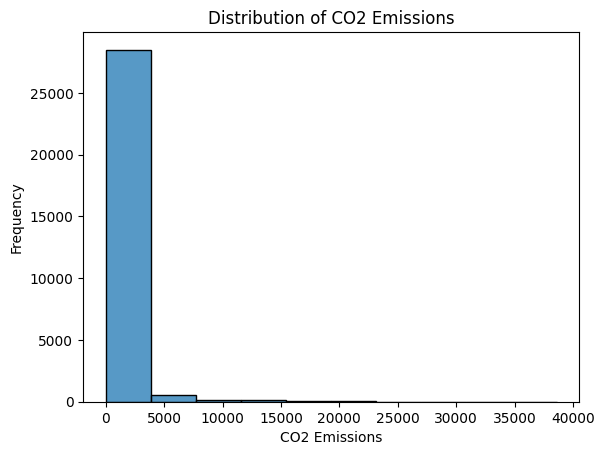

In [77]:
# Create a bar plot to visualize the distribution of CO2 emissions in the result DataFrame.
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(database_result['co2'], bins=10)
plt.title("Distribution of CO2 Emissions")
plt.xlabel("CO2 Emissions")
plt.ylabel("Frequency")
plt.show()

##### I prepared the above visualization using a bar plot to show the distribution of CO2 emissions across various countries.
##### The graph shows that the data is right-skewed meaning that few countries produce high emissions.

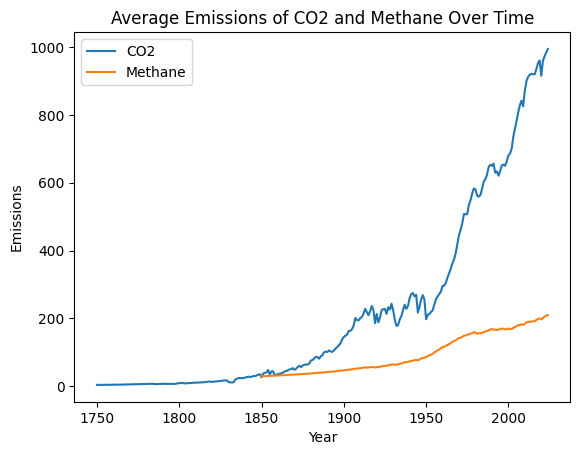

In [78]:
# Create a line plot to visualize the average CO2 and methane emissions over time.
yearly = database_result.groupby('year')[['co2', 'methane']].mean().reset_index()

plt.plot(yearly['year'], yearly['co2'], label='CO2')
plt.plot(yearly['year'], yearly['methane'], label='Methane')

plt.title("Average Emissions of CO2 and Methane Over Time")
plt.xlabel("Year")
plt.ylabel("Emissions")
plt.legend()
plt.show()

##### The above line plot shows how both CO2 and Methane emissions have changed over time.
##### This graph helps us identify the increasing trends of the emissions.

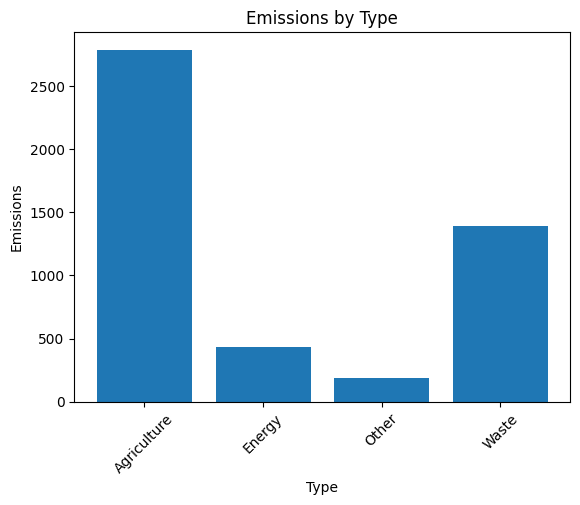

In [ ]:
# Create a bar plot to visualize the emissions by type.

region_emissions = Methane_final_df.groupby('type')['emissions'].mean()

plt.bar(region_emissions.index, region_emissions.values)

plt.title("Emissions by Type")
plt.xlabel("Type")
plt.ylabel("Emissions")
plt.xticks(rotation=45)

plt.show()

##### - The above bar plot shows a different type of methane emissions.
##### - Based on this graph I can tell that agriculture causes higher emissions than the rest.

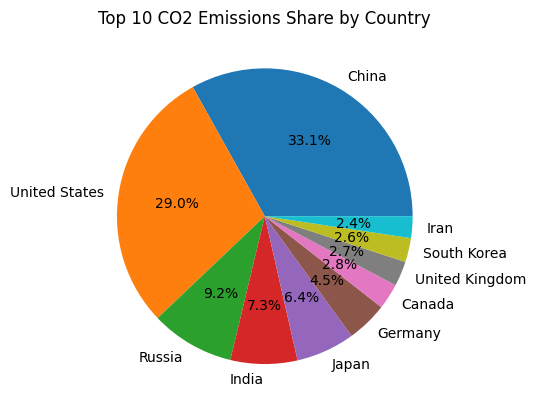

In [92]:
# Create a pie chart to visualize the share of CO2 emissions by country for the top 10 emitting countries.
top_co2 = Carbon_emissions_df.groupby('Country')['Kilotons of Co2'].sum().nlargest(10)

top_co2.plot(kind='pie', autopct='%1.1f%%')
plt.title("Top 10 CO2 Emissions Share by Country")
plt.show()

##### - The above pie chart shows emissions of the top 10 countries. This graph tells me that majority of the emsission are from these 10 countries.

In [94]:
Carbon_emissions_per_capita_df.sample(10)


,Entity,Year,Annual CO₂ emissions (per capita)
9007,North America,1937,11.020.559
19507,Cyprus,1992,6.793.458
25495,Croatia,2018,42.601.137
22981,France,2007,64.601.693
11410,Mozambique,1954,18.321.574
11584,Japan,1955,15.748.093
823,Singapore,1820,0
2737,Lower-middle-income countries,1864,19.550.114
19348,Luxembourg,1991,32.181.065
24158,Iran,2012,760.904


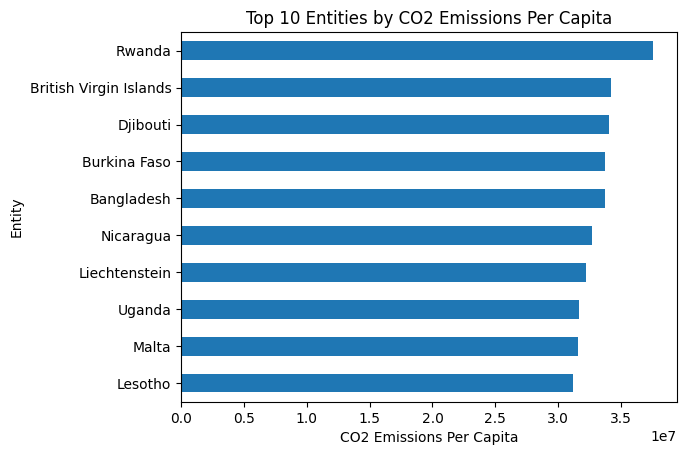

In [ ]:
# Create a horizontal bar plot to visualize the top 10 entities by CO2 emissions per capita. 

#convert the 'Annual CO₂ emissions (per capita)' column to numeric.
Carbon_emissions_per_capita_df['Annual CO₂ emissions (per capita)'] = pd.to_numeric(
    Carbon_emissions_per_capita_df['Annual CO₂ emissions (per capita)'],
    errors='coerce'
)

top_pc = Carbon_emissions_per_capita_df.groupby('Entity')['Annual CO₂ emissions (per capita)'].mean().nlargest(10)

top_pc.sort_values().plot(kind='barh')
plt.title("Top 10 Entities by CO2 Emissions Per Capita")
plt.xlabel("CO2 Emissions Per Capita")
plt.ylabel("Entity")
plt.show()

##### - This graph shows the top 10 entities(countries) CO2 emissions per person. Rwanda is the highest in CO2 emissions per capita.

## 2. Data Cleaning and Transformation

##### Clean up the data in database_result dataframe

In [122]:
#Check missing values in the database_result DataFrame.
database_result.isnull().sum()


country          0
year             0
co2              0
methane       5075
population    4021
dtype: int64

In [ ]:
# Drop rows where CO2 is missing, because CO2 is an essential data point for our analysis.
database_result = database_result.dropna(subset=['co2'])

# Fill population with median
database_result['population'] = database_result['population'].fillna(database_result['population'].median())
    
# Fill methane with median.
database_result['methane'] = database_result['methane'].fillna(database_result['methane'].median())

In [127]:
# Check again
database_result.isnull().sum()

country       0
year          0
co2           0
methane       0
population    0
dtype: int64

In [ ]:
# Dropping missing values from the result DataFrame.
result.dropna(inplace=True)

In [ ]:
# Checking for null values after dropping them.
result.isnull().sum()

country       0
year          0
co2           0
methane       0
population    0
dtype: int64

In [ ]:
# Checking the data types of the columns in the Carbon_emissions_df DataFrame.
print(Carbon_emissions_df.dtypes)

Country                       str
Region                        str
Date                          str
Kilotons of Co2           float64
Metric Tons Per Capita    float64
dtype: object


In [ ]:
# Checking the data types of the columns in the Carbon_emissions_per_capita_df DataFrame.
print(Carbon_emissions_per_capita_df.dtypes)

Entity                                 str
Year                                 int64
Annual CO₂ emissions (per capita)      str
dtype: object


In [ ]:
# Checking the data types of the columns in the result DataFrame.
print(result.dtypes)

country           str
year            int64
co2           float64
methane       float64
population    float64
dtype: object


##### Check for any outliers in the database_result dataframe

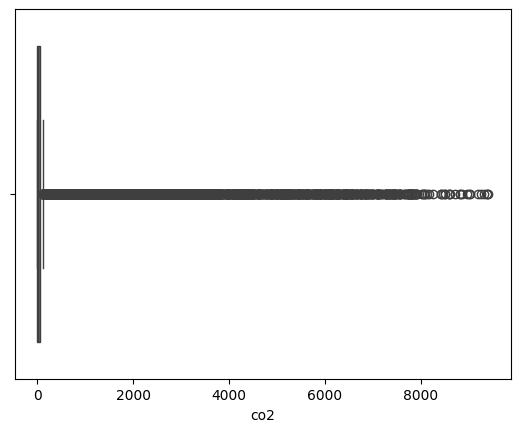

In [137]:
# Create a box plot to visualize the distribution of CO2 emissions in the result DataFrame.
sns.boxplot(x=database_result['co2'])
plt.show()

In [ ]:
# Remove outliers from the result DataFrame based on the CO2 emissions column.
# Calculate the 99th percentile of the CO2 emissions to identify outliers and filter out 
# those values from the database_result DataFrame.
database_result = database_result[database_result['co2'] < database_result['co2'].quantile(0.99)]

In [155]:
Methane_final_df.head()

,Unnamed: 0,region,country,emissions,type,segment,reason,baseYear,notes
0,0,Africa,algeria,257.611206,Agriculture,Total,All,2019-2021,Average based on United Nations Framework Conv...
1,1,Africa,algeria,0.052000,Energy,Bioenergy,All,2022,Estimates from end-uses are for 2020 or 2021 (...
2,2,Africa,algeria,130.798996,Energy,Gas pipelines and LNG facilities,Fugitive,2022,Not available
3,3,Africa,algeria,69.741898,Energy,Gas pipelines and LNG facilities,Vented,2022,Not available
4,4,Africa,algeria,213.987000,Energy,Onshore gas,Fugitive,2022,Not available


In [167]:
# Rename the columns in Methane_final_df to standardize the data sets
Methane_final_df = Methane_final_df.rename(columns={
    'country_name': 'country',
    'year': 'year'
})

print(Methane_final_df.columns)

Index(['region', 'country', 'emissions', 'type', 'segment', 'reason',
       'baseYear', 'notes'],
      dtype='str')


In [169]:
# Rename the carbon_emissions_df DataFrame columns to standardize the data sets.
Carbon_emissions_df = Carbon_emissions_df.rename(columns={
    'Country': 'country',
    'Kilotons of Co2': 'co2',
    'Metric Tons Per Capita': 'co2_per_capita'
})

In [170]:
print(Carbon_emissions_df.columns)

Index(['country', 'Region', 'Date', 'co2', 'co2_per_capita'], dtype='str')


In [180]:
Carbon_emissions_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5677 entries, 0 to 5676
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   country         5677 non-null   str           
 1   Region          5677 non-null   str           
 2   Date            5677 non-null   datetime64[us]
 3   co2             5677 non-null   float64       
 4   co2_per_capita  5677 non-null   float64       
 5   year            5677 non-null   int32         
dtypes: datetime64[us](1), float64(2), int32(1), str(2)
memory usage: 244.1 KB


In [183]:
# Add a new column year to the carbon_emissions_df DataFrame by extracting the year 
# from the Date column. This will be used to join to the other data frames.

#Convert the Date column to date format.
Carbon_emissions_df['Date'] = pd.to_datetime(Carbon_emissions_df['Date'], errors='coerce')

#Extract the year from the Date column.
Carbon_emissions_df['year'] = Carbon_emissions_df['Date'].dt.year

Carbon_emissions_df[['Date', 'year']].head()

,Date,year
0,2011-01-01,2011
1,2012-01-01,2012
2,2010-01-01,2010
3,2019-01-01,2019
4,2018-01-01,2018


In [172]:
Carbon_emissions_per_capita_df = Carbon_emissions_per_capita_df.rename(columns={
    'Entity': 'country',
    'Year': 'year',
    'Annual CO₂ emissions (per capita)': 'co2_per_capita'
})

In [173]:
print(Carbon_emissions_per_capita_df.columns)

Index(['country', 'year', 'co2_per_capita'], dtype='str')


In [ ]:
# Change the data for country to be uniform accross all the datasets.
# This will help us join the datasets together.

Methane_final_df['country'] = Methane_final_df['country'].str.lower().str.strip()
Carbon_emissions_df['Country'] = Carbon_emissions_df['Country'].str.lower().str.strip()
Carbon_emissions_per_capita_df['Entity'] = Carbon_emissions_per_capita_df['Entity'].str.lower().str.strip()

database_result['country'] = database_result['country'].str.lower().str.strip()

## Resources and References
*What resources and references have you used for this project?*
📝 <!-- Answer Below -->

I used the lecture videos predominantly to help me with this project and I also used the course notes.

My datasets were imported from kaggle: https://www.kaggle.com

I also got data from our world in data website: 
https://ourworldindata.org/co2-and-greenhouse-gas-emissions?insight=many-countries-have-reduced-their-co2-emissions#key-insights

In [184]:
# ⚠️ Make sure you run this cell at the end of your notebook before every submission!
!jupyter nbconvert --to python source.ipynb

[NbConvertApp] Converting notebook source.ipynb to python
[NbConvertApp] Writing 15718 bytes to source.py
